# Sales Data Analysis Using Python 
## Project Objective
This project analyzers sales data to find useful bussiness insights.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.linear_model import LinearRegression



In [4]:
df = pd.read_csv(r"C:\Users\ALFAIZ KHAN\OneDrive\Desktop\Csv_files\Sales_Data.csv")
df.head()

,Order_Date,Product,Category,Region,Sales,Quantity,Discount,Profit
0,2025-01-01,Tablet,Electronics,East,2077.44,7,0.05,279.20
1,2025-01-04,Keyboard,Accessories,South,42.24,1,0.05,9.48
2,2025-01-08,Mouse,Accessories,South,94.98,4,0.10,20.75
3,2025-01-12,Tablet,Electronics,West,1090.10,4,0.15,141.46
4,2025-01-15,Headphones,Accessories,South,385.77,5,0.05,85.70


In [5]:
df.shape

(100, 8)

In [8]:
df.columns

Index(['Order_Date', 'Product', 'Category', 'Region', 'Sales', 'Quantity',
       'Discount', 'Profit'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_Date  100 non-null    object 
 1   Product     100 non-null    object 
 2   Category    100 non-null    object 
 3   Region      100 non-null    object 
 4   Sales       100 non-null    float64
 5   Quantity    100 non-null    int64  
 6   Discount    100 non-null    float64
 7   Profit      100 non-null    float64
dtypes: float64(3), int64(1), object(4)
memory usage: 6.4+ KB


In [10]:
df.isnull().sum()

Order_Date    0
Product       0
Category      0
Region        0
Sales         0
Quantity      0
Discount      0
Profit        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

In [13]:
df ['Order_Date'] = pd.to_datetime(df['Order_Date'])

df.head()

,Order_Date,Product,Category,Region,Sales,Quantity,Discount,Profit
0,2025-01-01,Tablet,Electronics,East,2077.44,7,0.05,279.20
1,2025-01-04,Keyboard,Accessories,South,42.24,1,0.05,9.48
2,2025-01-08,Mouse,Accessories,South,94.98,4,0.10,20.75
3,2025-01-12,Tablet,Electronics,West,1090.10,4,0.15,141.46
4,2025-01-15,Headphones,Accessories,South,385.77,5,0.05,85.70


In [14]:
df.dtypes

Order_Date    datetime64[ns]
Product               object
Category              object
Region                object
Sales                float64
Quantity               int64
Discount             float64
Profit               float64
dtype: object

# Total sales and profit

In [20]:
total_sales = df['Sales'].sum()
total_sales
print('Total Sales :', total_sales)

Total Sales : 95618.50000000001


In [21]:
total_profit = df['Profit'].sum()
total_profit
print('Total Profit :', total_profit)

Total Profit : 14225.98


In [22]:
total_quantity = df['Quantity'].sum()
total_quantity
print('Total Quantity:', total_quantity)

Total Quantity: 518


# Average sales 

In [23]:
average_sales = np.mean(df['Sales'])
print('Average Sales :', average_sales)

Average Sales : 956.1850000000002


# Highest-selling product

In [27]:
product_sales = df.groupby('Product')['Sales'].sum()
print (product_sales.sort_values(ascending =False))

Product
Laptop        29124.01
Mobile        14792.73
Monitor       14722.45
Tablet        14413.20
Printer       11914.77
Headphones     5081.66
Keyboard       4166.41
Mouse          1403.27
Name: Sales, dtype: float64


In [29]:
best_product = product_sales.idxmax()
print('Best Slling Product:',best_product)

Best Slling Product: Laptop


# Category wise sales

In [34]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales

Category
Accessories        10651.34
Electronics        73052.39
Office Supplies    11914.77
Name: Sales, dtype: float64

# Region-wise profit 


In [35]:
region_profit = df.groupby('Region')['Profit'].sum()
print(region_profit)

Region
East     4297.99
North    3759.62
South    3767.63
West     2400.74
Name: Profit, dtype: float64


# Graphs 
## Category-wise Sales 

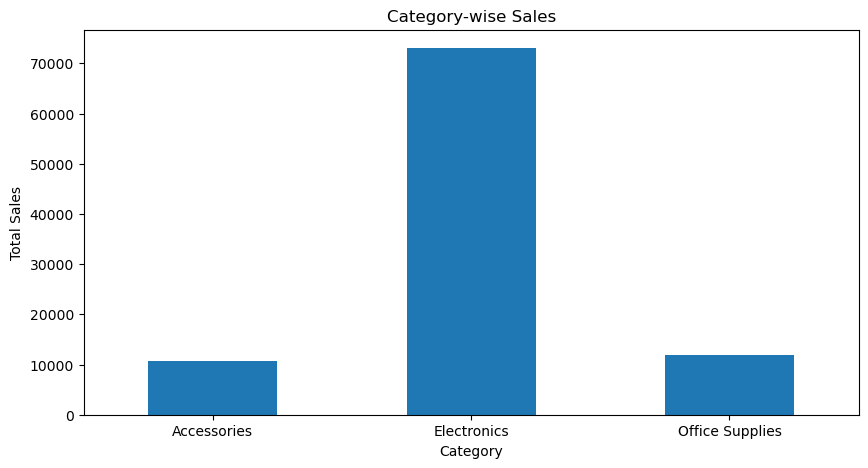

In [38]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot (kind ='bar',figsize =(10,5))

plt.title('Category-wise Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()
                     

### Region-wise profit

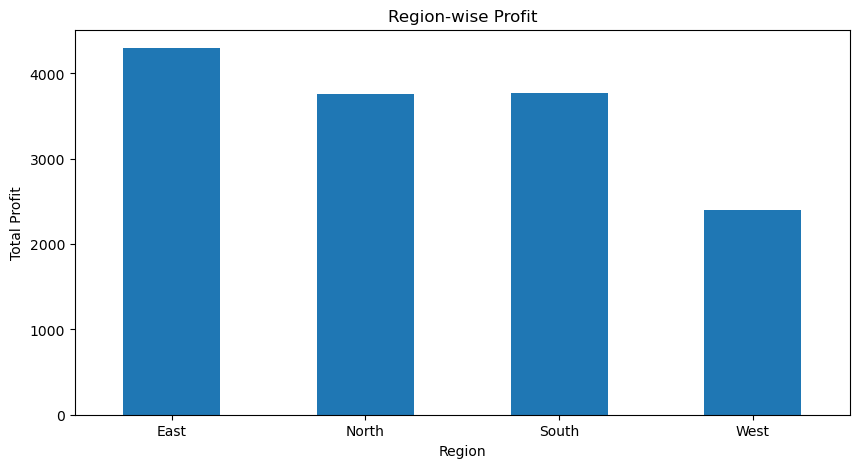

In [39]:
region_profit = df.groupby('Region')['Profit'].sum()

region_profit.plot (kind ='bar',figsize =(10,5))

plt.title('Region-wise Profit')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.show()

### Show Sales Distribution with Graph..

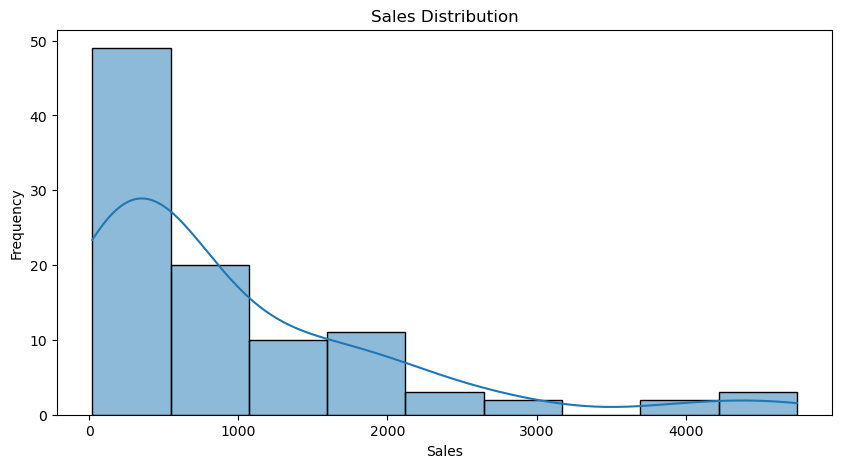

In [49]:
plt.figure(figsize=(10,5))

sns.histplot(df['Sales'],kde =True)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()


### Sales vs Profit

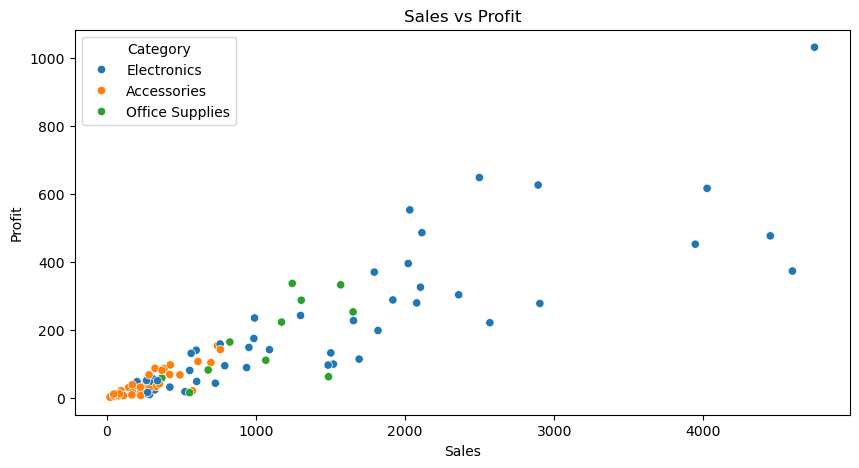

In [42]:
plt.figure(figsize=(10,5))

sns.scatterplot(data=df,x='Sales',y='Profit',  hue='Category')

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

### Monthly Sales Trend

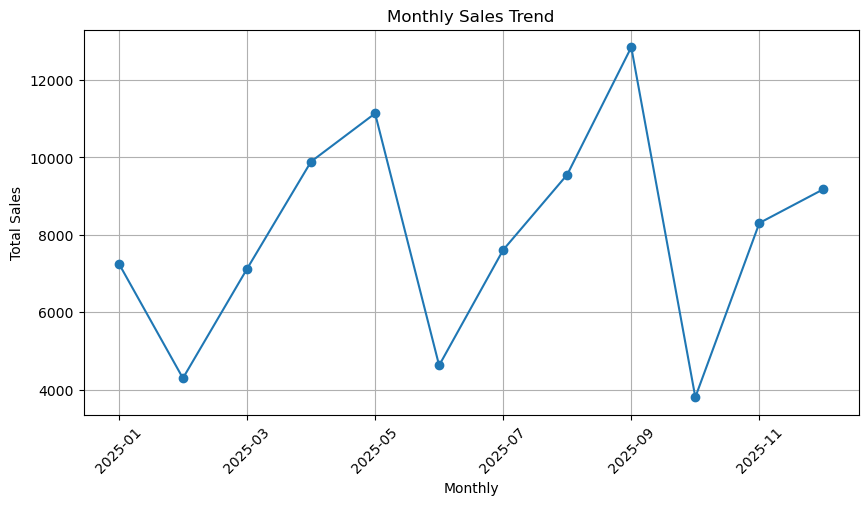

In [47]:
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot (kind ='line', marker= "o", figsize =(10,5))

plt.title('Monthly Sales Trend')
plt.xlabel('Monthly')
plt.ylabel('Total Sales')
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

### Numpy--Sales statistics

In [50]:
sales_array = np.array(df['Sales'])


print('Minimum Sales:',np.min(sales_array))
print('Maximum Sales:',np.max(sales_array))
print('Mean Sales:',np.mean(sales_array))
print('Standard Deviation:',np.std(sales_array))

Minimum Sales: 21.09
Maximum Sales: 4744.91
Mean Sales: 956.1850000000002
Standard Deviation: 1062.4382785032738


### Optional Sales Prediction

In [52]:
df ['Order_Number'] = np.arange(1,len(df)+1)

X = df[['Order_Number']]
y = df['Sales']

model = LinearRegression()
model.fit(X,y)

predicted_sales = model.predict([[101]])

print("Predicted Sales:",predicted_sales)


Predicted Sales: [1095.0536]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [54]:
df ['Order_Number'] = np.arange(1,len(df)+1)

X = df[['Order_Number']]
y = df['Sales']

model = LinearRegression()
model.fit(X,y)

predicted_sales = model.predict([[102]])

print("Predicted Sales:",predicted_sales)

Predicted Sales: [1097.80347327]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [55]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())

print("\nBest-Selling Product:")
print(df.groupby("Product")["Sales"].sum().idxmax())

print("\nHighest-Performing Region:")
print(df.groupby("Region")["Sales"].sum().idxmax())

print("\nBest Category:")
print(df.groupby("Category")["Sales"].sum().idxmax())

print("\nHighest Profit Region:")
print(df.groupby("Region")["Profit"].sum().idxmax())

print("\nSales-Profit Correlation:")
print(df["Sales"].corr(df["Profit"]))

Total Sales: 95618.50000000001
Total Profit: 14225.98

Best-Selling Product:
Laptop

Highest-Performing Region:
East

Best Category:
Electronics

Highest Profit Region:
East

Sales-Profit Correlation:
0.8768692204614207


# Conclusion

## Key Findings

- Total sales generated were ₹95,618.50.
- Total profit generated was ₹14,225.98.
- The best-selling product was Laptop.
- The highest-performing region was East.
- The Electronics category generated the highest sales.
- Monthly sales trends can be analyzed using the monthly sales chart.

## Business Insights

- The Electronics category generated the highest sales.
- The East region generated the highest profit.
- Laptop was the best-selling product.
- The correlation between sales and profit was 0.877.
- There is a strong positive relationship between sales and profit.
- Higher sales generally lead to higher profit.

## Future Improvements

- Add more real-world sales data.
- Create an interactive Power BI dashboard.
- Analyze customer buying behavior.
- Add sales forecasting in the future.
- Compare sales performance across different months and regions.